In [1]:
import pandas as pd

df = pd.read_csv("/Users/saiyambardia/heart-disease-prediction/data/cleveland_cleaned.csv")

In [2]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [3]:
df.shape

(303, 14)

In [4]:
X = df.drop(['target'], axis=1)
y = df.target

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(X,y,test_size=0.2, train_size=0.8, random_state=0)

print(f"Shape of X_train {X_train.shape}")
print(f"Shape of X_valid {X_valid.shape}")
print(f"Shape of y_train {y_train.shape}")
print(f"Shape of y_valid {y_valid.shape}")

Shape of X_train (242, 13)
Shape of X_valid (61, 13)
Shape of y_train (242,)
Shape of y_valid (61,)


## 1. Logistic Regression

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train,y_train)
y_pred = pipeline.predict(X_valid)

In [10]:
print(f"Accuracy Score: {accuracy_score(y_valid, y_pred):.2f}\n")
print("Confusion Matrix:")
print(confusion_matrix(y_valid, y_pred))
print("\nClassification Report:")
print(classification_report(y_valid, y_pred))

Accuracy Score: 0.79

Confusion Matrix:
[[31  4]
 [ 9 17]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.89      0.83        35
           1       0.81      0.65      0.72        26

    accuracy                           0.79        61
   macro avg       0.79      0.77      0.78        61
weighted avg       0.79      0.79      0.78        61



Observations:
- The `LogisticRegression` model gives us an accuracy score of 0.79.
- The confusion matrix shows us that model falsely identifies 9 patients with CAD as healthy and 4 patients with no CAD are identified as with CAD
- Model is better at finding healthy patients (recall 0.89) than CAD patients (recall 0.65)
- CAD recall of 0.65 means the model misses 35% of actual CAD cases

## 2. Random Forest Model

In [14]:
from sklearn.ensemble import RandomForestClassifier

forest_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('forest_model', RandomForestClassifier(random_state=0))
])

forest_pipeline.fit(X_train,y_train)
forest_preds = forest_pipeline.predict(X_valid)

In [15]:
print(f"Accuracy Score: {accuracy_score(y_valid, forest_preds):.2f}\n")
print("Confusion Matrix:")
print(confusion_matrix(y_valid, forest_preds))
print("\nClassification Report:")
print(classification_report(y_valid, forest_preds))

Accuracy Score: 0.75

Confusion Matrix:
[[30  5]
 [10 16]]

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.86      0.80        35
           1       0.76      0.62      0.68        26

    accuracy                           0.75        61
   macro avg       0.76      0.74      0.74        61
weighted avg       0.76      0.75      0.75        61



In [18]:
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=0)

param_grid = {
    'n_estimators': [100,200,300],
    'max_depth': [None,3,5,10],
    'min_samples_split': [2,5,10]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    verbose = 2
)

grid_search.fit(X_train,y_train)

print("Best Hyperparameters: ", grid_search.best_params_)
best_rf_model = grid_search.best_estimator_

Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV] END max_depth=None, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, min_samples_split=2, n_estimators=200; total time=   0.1s
[CV] END max_depth=None, min_samples_split=2, n_estimators=200; total time=   0.1s
[CV] END max_depth=None, min_samples_split=2, n_estimators=200; total time=   0.1s
[CV] END max_depth=None, min_samples_split=2, n_estimators=200; total time=   0.1s
[CV] END max_depth=None, min_samples_split=2, n_estimators=200; total time=   0.1s
[CV] END max_depth=None, min_samples_split=2, n_estimators=300; total time=   0.2s
[CV] END max_depth=None, 

In [19]:
forest_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('forest_model', RandomForestClassifier(
        random_state=0,
        n_estimators=100,
        max_depth=None,
        min_samples_split=10))
])

forest_pipeline.fit(X_train,y_train)
forest_preds = forest_pipeline.predict(X_valid)

In [20]:
print(f"Accuracy Score: {accuracy_score(y_valid, forest_preds):.2f}\n")
print("Confusion Matrix:")
print(confusion_matrix(y_valid, forest_preds))
print("\nClassification Report:")
print(classification_report(y_valid, forest_preds))

Accuracy Score: 0.75

Confusion Matrix:
[[30  5]
 [10 16]]

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.86      0.80        35
           1       0.76      0.62      0.68        26

    accuracy                           0.75        61
   macro avg       0.76      0.74      0.74        61
weighted avg       0.76      0.75      0.75        61



**Observation:**
Random Forest (75%) underperformed compared to Logistic Regression (79%). 
This is likely due to the small dataset size (303 rows) where simpler 
linear models tend to generalize better. GridSearchCV confirmed default 
parameters were already optimal.

## 3. Extreme Gradient Boosting

In [26]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=500,
    early_stopping_rounds=10,
    learning_rate=0.05,
    max_depth=4,
    random_state=0,
    n_jobs=-1,
    eval_metric='logloss'
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=False
)

xgb_preds = xgb_model.predict(X_valid)

In [27]:
print(f"Accuracy Score: {accuracy_score(y_valid, xgb_preds):.2f}\n")
print("Confusion Matrix:")
print(confusion_matrix(y_valid, xgb_preds))
print("\nClassification Report:")
print(classification_report(y_valid, xgb_preds))

Accuracy Score: 0.77

Confusion Matrix:
[[30  5]
 [ 9 17]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.86      0.81        35
           1       0.77      0.65      0.71        26

    accuracy                           0.77        61
   macro avg       0.77      0.76      0.76        61
weighted avg       0.77      0.77      0.77        61



## 4. K-Nearest Neighbors

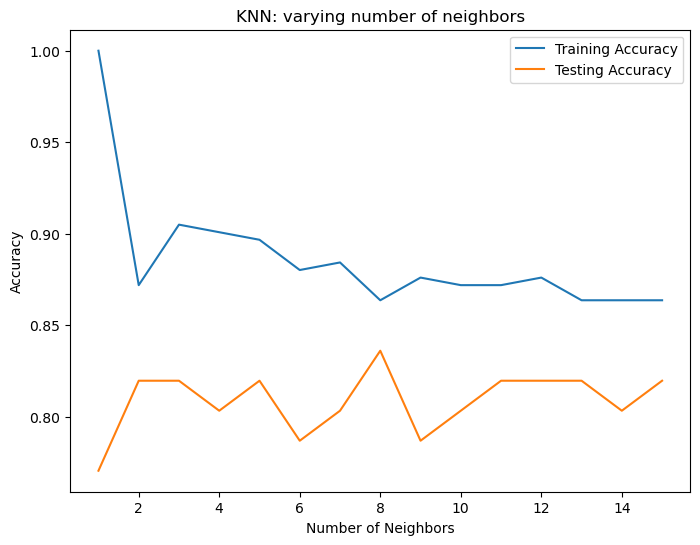

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

neighbors = np.arange(1,16)
train_accuracies = {}
test_accuracies = {}
for i in neighbors:
    knn_pipeline = Pipeline(steps=[
        ('scaler',StandardScaler()),
        ('knn_model',KNeighborsClassifier(n_neighbors=i))
    ])
    knn_pipeline.fit(X_train,y_train)
    train_accuracies[i] = knn_pipeline.score(X_train,y_train)
    test_accuracies[i] = knn_pipeline.score(X_valid,y_valid)

plt.figure(figsize=(8,6))
plt.title("KNN: varying number of neighbors")
plt.plot(neighbors, train_accuracies.values(), label='Training Accuracy')
plt.plot(neighbors, test_accuracies.values(), label='Testing Accuracy')
plt.xlabel('Number of Neighbors')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [34]:
knn_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('knn_model', KNeighborsClassifier(n_neighbors=8))
])

knn_pipeline.fit(X_train,y_train)
knn_preds = knn_pipeline.predict(X_valid)

In [35]:
print(f"Accuracy Score: {accuracy_score(y_valid,knn_preds)} \n")
print(f"Confusion Matrix : \n")
print(confusion_matrix(y_valid, knn_preds))
print("Classification Report: \n")
print(classification_report(y_valid,knn_preds))

Accuracy Score: 0.8360655737704918 

Confusion Matrix : 

[[34  1]
 [ 9 17]]
Classification Report: 

              precision    recall  f1-score   support

           0       0.79      0.97      0.87        35
           1       0.94      0.65      0.77        26

    accuracy                           0.84        61
   macro avg       0.87      0.81      0.82        61
weighted avg       0.86      0.84      0.83        61



KNN with k=8 achieved the highest accuracy (84%) and precision (0.94) 
across all models. However recall for CAD remains consistently at 0.65 
across all four models despite all 13 features being present, strongly 
suggesting that dataset size (303 rows) is the primary bottleneck. 
Combining all four UCI hospital datasets (~920 rows total) would likely 
improve recall significantly.